<a href="https://colab.research.google.com/github/ZhengyuEddy/ML-For-Beginners/blob/main/2-Regression/2-Data/solution/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear Regression for Pumpkins - Lesson 2

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# *** IMPORTANT: Replace 'YOUR_RAW_GITHUB_URL_HERE' with the actual raw URL of your CSV file on GitHub ***
pumpkins = pd.read_csv('https://raw.githubusercontent.com/microsoft/ML-For-Beginners/refs/heads/main/2-Regression/data/US-pumpkins.csv')

pumpkins = pumpkins[pumpkins['Package'].str.contains('bushel', case=True, regex=True)]

pumpkins.head()  # pumpkins.tail()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
1738,ST. LOUIS,NaN,1/2 bushel cartons,MINIATURE,FLAT TYPE,NaN,9/30/16,15.00,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.
1739,ST. LOUIS,NaN,1/2 bushel cartons,MINIATURE,FLAT TYPE,NaN,9/30/16,13.75,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.
1740,ST. LOUIS,NaN,1/2 bushel cartons,MINIATURE,FLAT TYPE,NaN,9/30/16,10.75,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.
1741,ST. LOUIS,NaN,1/2 bushel cartons,MINIATURE,FLAT TYPE,NaN,9/30/16,12.00,12.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.
1742,ST. LOUIS,NaN,1/2 bushel cartons,MINIATURE,FLAT TYPE,NaN,9/30/16,12.00,12.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,LOWER.


In [10]:
pumpkins.isnull().sum()

,0
City Name,0
Type,406
Package,0
Variety,0
Sub Variety,167
Grade,415
Date,0
Low Price,0
High Price,0
Mostly Low,24


In [27]:
# A set of new columns for a new dataframe. Filter out nonmatching columns
columns_to_select = ['Package', 'Low Price', 'High Price', 'Date']
pumpkins = pumpkins.loc[:, columns_to_select]

# Get an average between low and high price for the base pumpkin price
price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

# Convert the date to its month only
month = pd.DatetimeIndex(pumpkins['Date']).month

# Create a new dataframe with this basic data
new_pumpkins = pd.DataFrame({'Month': month, 'Package': pumpkins['Package'], 'Low Price': pumpkins['Low Price'],'High Price': pumpkins['High Price'], 'Price': price})

# Convert the price if the Package contains fractional bushel values
print(new_pumpkins)

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'), 'Price'] = price/(1 + 1/9)

new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price/(1/2)

print(new_pumpkins)

      Month               Package  Low Price  High Price   Price
70        9  1 1/9 bushel cartons      15.00        15.0  15.000
71        9  1 1/9 bushel cartons      18.00        18.0  18.000
72       10  1 1/9 bushel cartons      18.00        18.0  18.000
73       10  1 1/9 bushel cartons      17.00        17.0  17.000
74       10  1 1/9 bushel cartons      15.00        15.0  15.000
...     ...                   ...        ...         ...     ...
1738      9    1/2 bushel cartons      15.00        15.0  15.000
1739      9    1/2 bushel cartons      13.75        15.0  14.375
1740      9    1/2 bushel cartons      10.75        15.0  12.875
1741      9    1/2 bushel cartons      12.00        12.0  12.000
1742      9    1/2 bushel cartons      12.00        12.0  12.000

[415 rows x 5 columns]
      Month               Package  Low Price  High Price  Price
70        9  1 1/9 bushel cartons      15.00        15.0  13.50
71        9  1 1/9 bushel cartons      18.00        18.0  16.20
72  

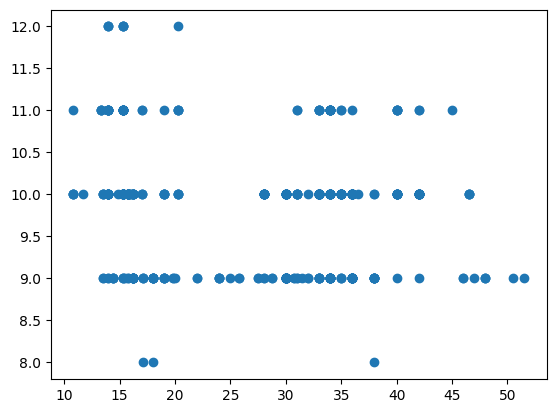

In [28]:
price = new_pumpkins.Price
month = new_pumpkins.Month
plt.scatter(price, month)
plt.show()


Month  Package             
8      1 1/9 bushel cartons    17.550000
       1/2 bushel cartons      38.000000
9      1 1/9 bushel cartons    16.299265
       1 1/9 bushel crates     13.950000
       1/2 bushel cartons      33.261364
       bushel baskets          49.250000
       bushel cartons          22.454545
10     1 1/9 bushel cartons    15.130102
       1 1/9 bushel crates     15.177273
       1/2 bushel cartons      35.094017
       bushel baskets          44.500000
       bushel cartons          25.043478
11     1 1/9 bushel cartons    15.372000
       1 1/9 bushel crates     13.950000
       1/2 bushel cartons      35.392857
       bushel baskets          45.000000
       bushel cartons          17.666667
12     1 1/9 bushel cartons    15.621429
       1 1/9 bushel crates     13.950000
Name: Price, dtype: float64
                            Low Price  High Price
Month Package                                    
8     1 1/9 bushel cartons  19.000000   20.000000
      1/2 bushe

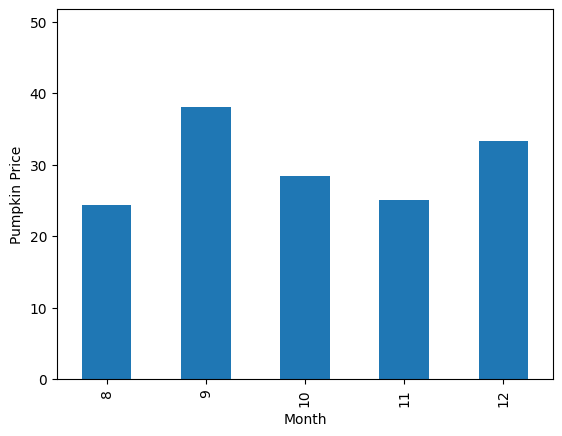

In [40]:
new_pumpkins.groupby(['Month','Package'])['Price'].mean().plot(kind='bar')
plt.ylabel("Pumpkin Price")

new_pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar')
plt.ylabel("Pumpkin Price")


tmp = new_pumpkins.groupby(['Month','Package'])['Price'].mean()
print(tmp)
tmp = new_pumpkins.groupby(['Month','Package'])[['Low Price', 'High Price']].mean()
print(tmp)